## Run CITE-pool (Integration and Clustering)

In [1]:
import scanpy as sc 
import pandas as pd
import RunCITEpool
import numpy as np

In [2]:
data_path = ['./datasets/example/1/data.h5ad','./datasets/example/2/data.h5ad','./datasets/example/3/data.h5ad']
output_path = './outputs/example/'
cutoff = 0.1
current_treepath = None#'./outputs/example/'
FinetuneNonde = [5]
ifretrain = False


RunCITEpool.main(data_path, output_path, cutoff, 
                current_treepath, FinetuneNonde, ifretrain)


Read data and run CITE-pool.
dataset 1 batch num: 1 ADT num: 191
dataset 2 batch num: 1 ADT num: 99
dataset 3 batch num: 1 ADT num: 228
=== Best Feature: CD35 : 4.501177739379674 in 2 datasets ===
(2760, 37502) (2760, 191)


ValueError: Value passed for key 'marker' is of incorrect shape. Values of obsm must match dimensions ('obs',) of parent. Value had shape (3706,) while it should have had (2760,).

## Results Visualization

### Loading Data

#### Option 1: Load datasets under different folders in data_path

In [21]:
## Load and concat RNA data
inbatch, adtdata, rnadata = [1], {}, {}
for i in range(len(data_path)):
    data = sc.read_h5ad(data_path[i])
    batch = data.obs['batch'].cat.categories
    # adtdata[i] = data[:,data.var['feature_types']=='Antibody Capture']     
    rnadata[i] = data[:,data.var['feature_types']=='Gene Expression']
    rnadata[i].obs['pred'] = None


    for j in range(len(batch)):
        file = str(i+1)+'/'+str(j+np.sum(inbatch))
        leaflabel = pd.read_csv(output_path+file+'/leaf_labels.csv',index_col=0)
        treelabel = pd.read_csv(output_path+file+'/treelabel.csv',index_col=0)
        embedding = pd.read_csv(output_path+file+'/embedding.csv',index_col=0)
        indices = rnadata[i].obs_names.isin(leaflabel.index)
        rnadata[i].obs['pred'][indices] = leaflabel['Label']
        
        if j == 0:
            rnadata[i].obsm['treelabel'] = np.zeros((rnadata[i].shape[0],embedding.shape[1]))
            rnadata[i].obsm['embedding'] = np.zeros((rnadata[i].shape[0],embedding.shape[1]))
        rnadata[i].obsm['treelabel'][indices] = treelabel.values
        rnadata[i].obsm['embedding'][indices] = embedding.values


    inbatch.append(j+1)

adata = sc.concat(rnadata.values(), axis=0, join='inner')

adata.write_h5ad(output_path+'reuslt.h5ad')

#### Option 2: If datasets concatenated, directly load results

In [ ]:
adata = sc.read_h5ad(output_path+'reuslt.h5ad')

for i in range(len(data_path)):
    
    batch = data.obs['batch'].cat.categories

    for j in range(len(batch)):
        file = str(i+1)+'/'+str(j+np.sum(inbatch))
        leaflabel = pd.read_csv(output_path+file+'/leaf_labels.csv',index_col=0)
        treelabel = pd.read_csv(output_path+file+'/treelabel.csv',index_col=0)
        embedding = pd.read_csv(output_path+file+'/embedding.csv',index_col=0)
        indices = rnadata[i].obs_names.isin(leaflabel.index)
        rnadata[i].obs['pred'][indices] = leaflabel['Label']
        
        if j == 0:
            rnadata[i].obsm['treelabel'] = np.zeros((rnadata[i].shape[0],embedding.shape[1]))
            rnadata[i].obsm['embedding'] = np.zeros((rnadata[i].shape[0],embedding.shape[1]))
        rnadata[i].obsm['treelabel'][indices] = treelabel.values
        rnadata[i].obsm['embedding'][indices] = embedding.values


    inbatch.append(j+1)


### Integrated data umap visualization with embedding

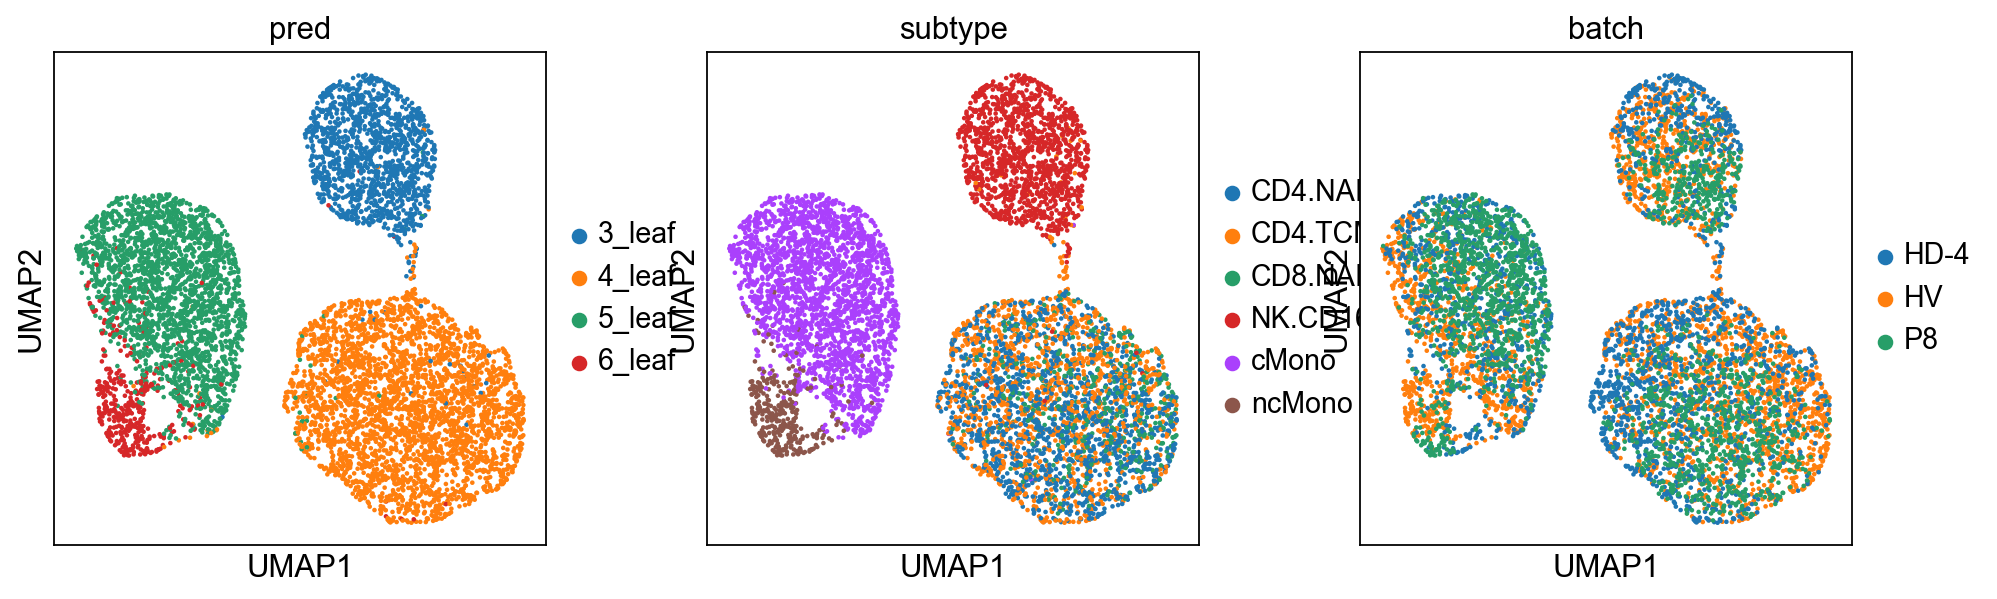

In [22]:
sc.set_figure_params(facecolor='white')
sc.pp.neighbors(adata, n_neighbors=10, use_rep='embedding', key_added='embedding')
sc.tl.umap(adata, neighbors_key='embedding')
sc.pl.umap(adata, color=['pred','subtype','batch'])

### Visualization of each embedding

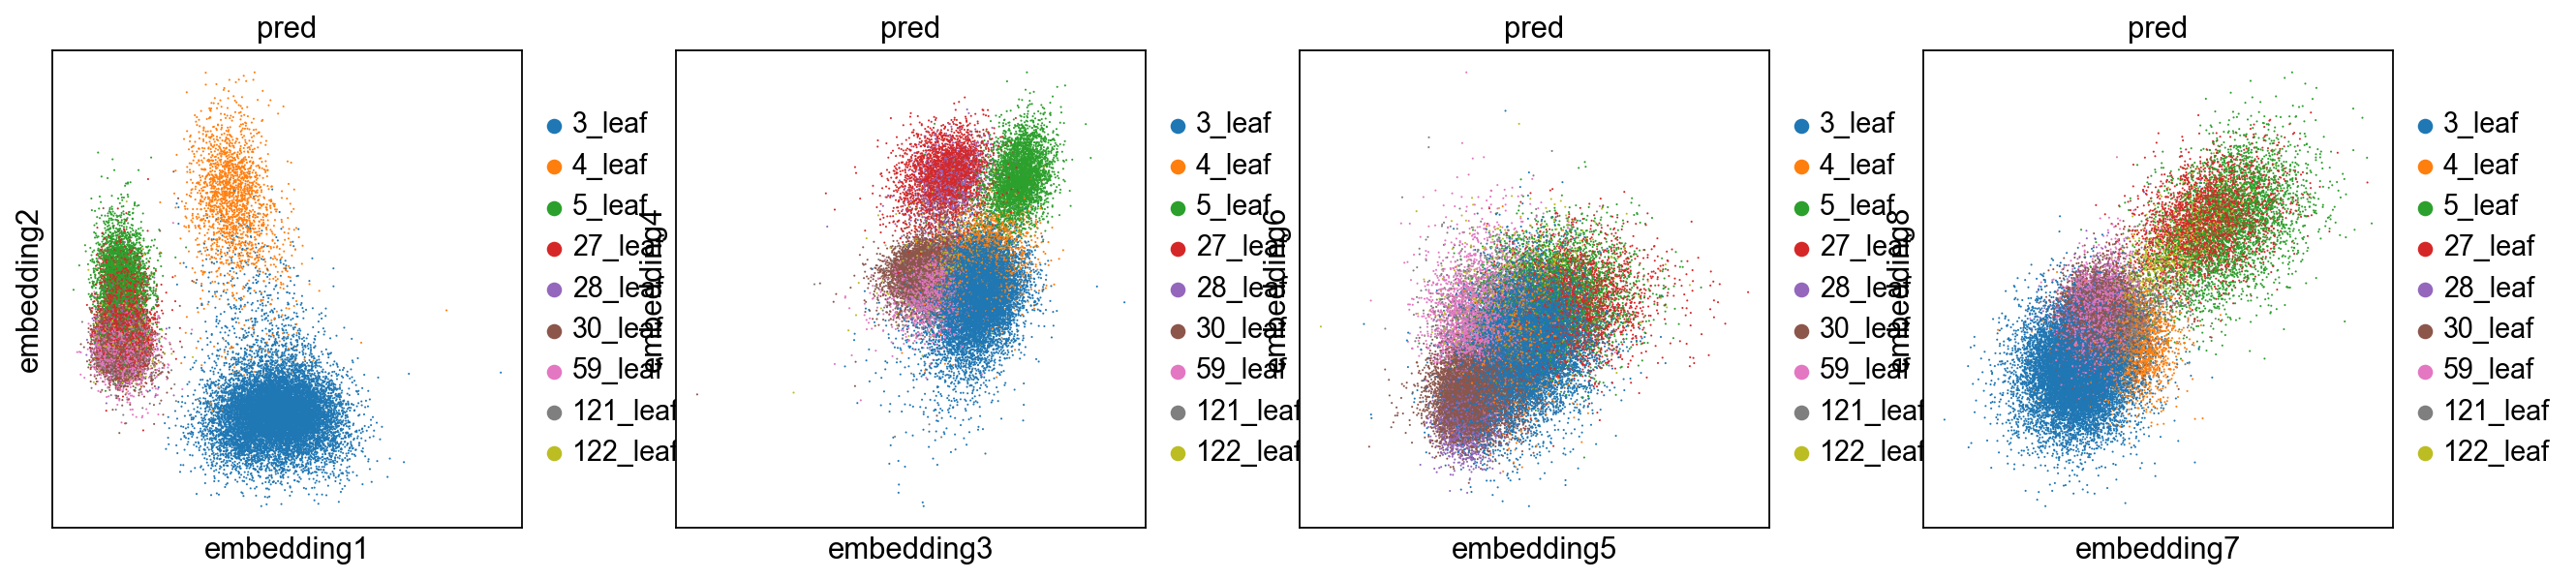

In [57]:
sc.pl.embedding(adata, basis='embedding', components=['1,2','3,4','5,6','7,8'],color=['subtype'])

## Advanced Analysis

### Bimodal property of Pseudo-marker at each node layer

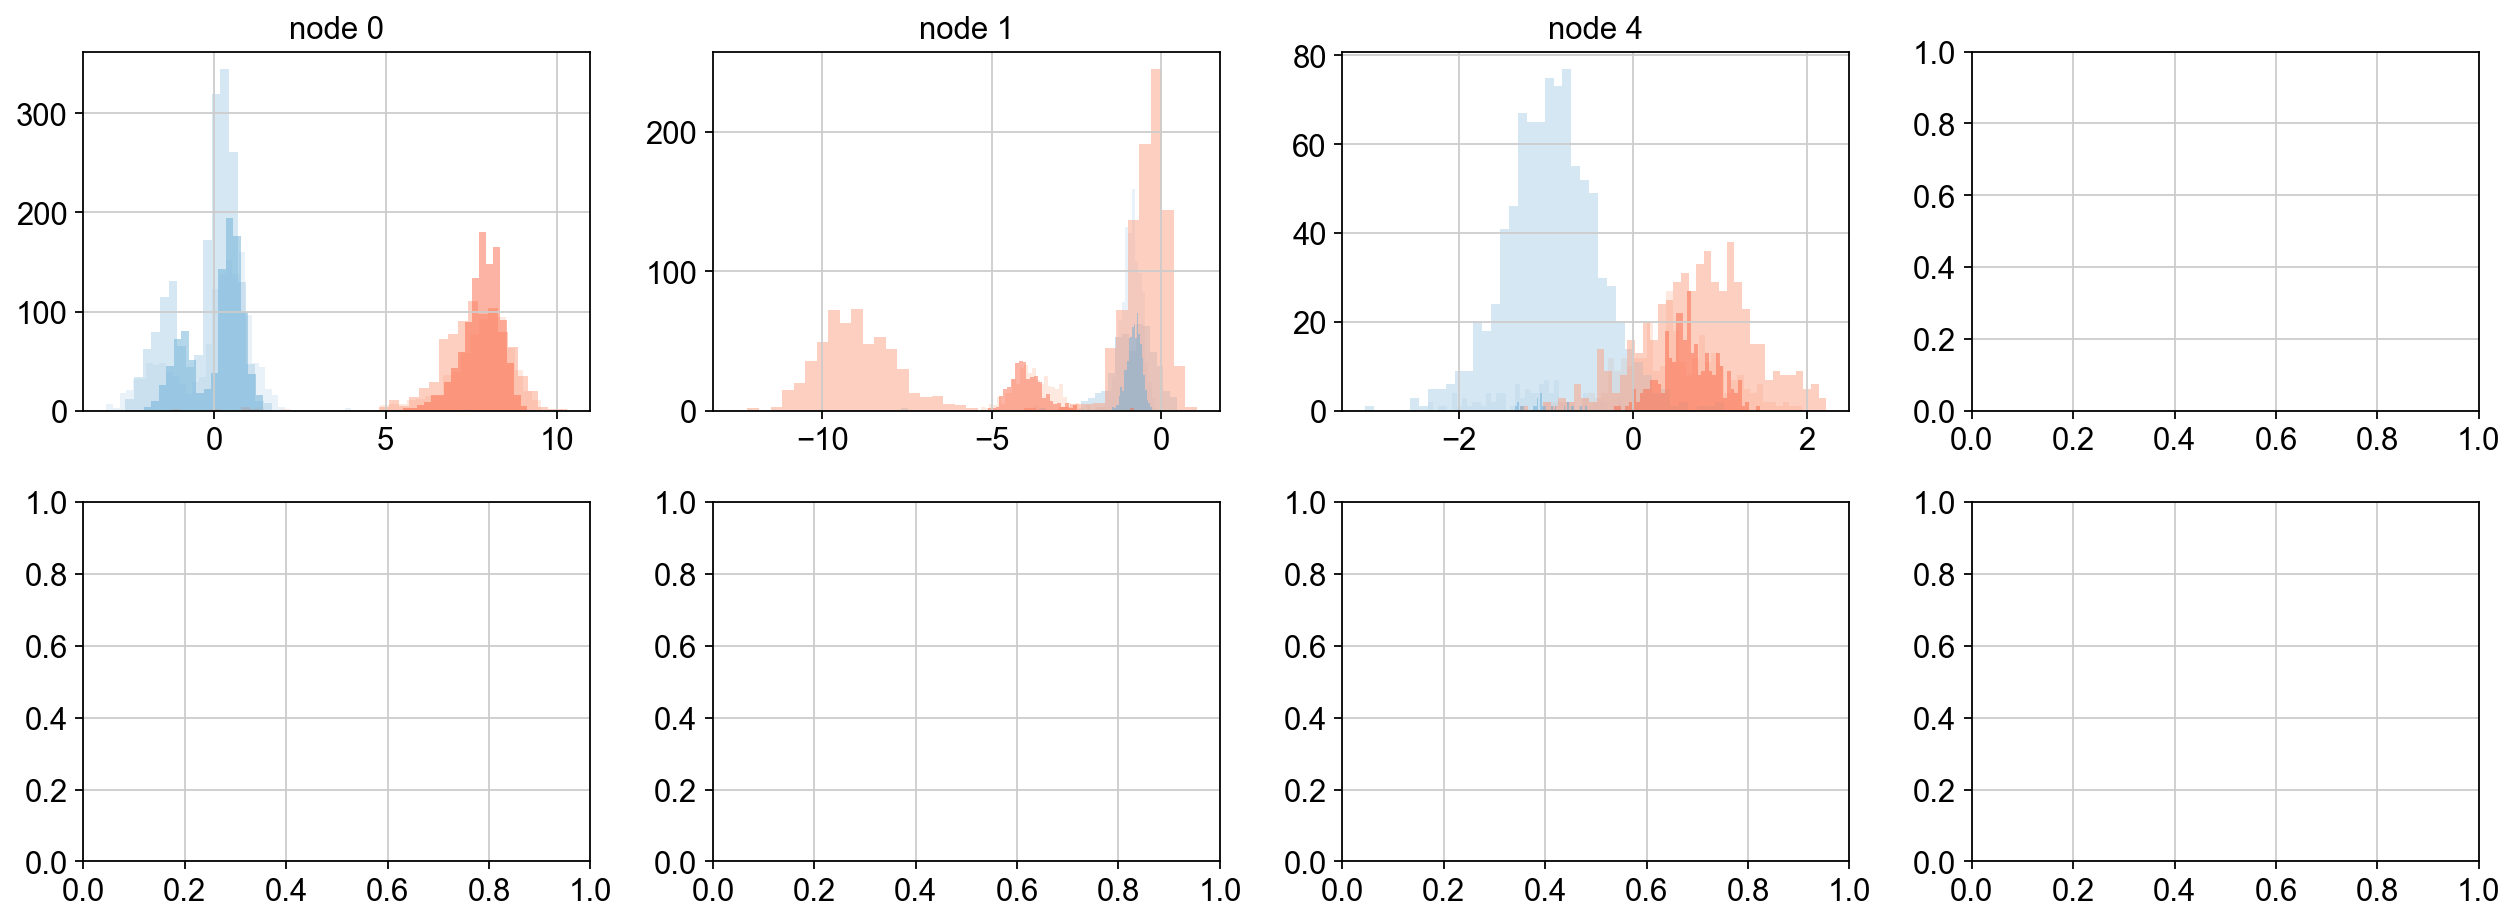

In [8]:
tree_label = pd.DataFrame(adata.obsm['treelabel'], index=adata.obs_names, columns=treelabel.columns)

nbatch = 6
import matplotlib.pyplot as plt
import numpy as np
blue_colors = [plt.cm.Blues((x+1)/nbatch) for x in range(nbatch)]  # 浅蓝到深蓝
red_colors =[plt.cm.Reds((x+1)/nbatch) for x in range(nbatch)]    # 浅红到深红

fig, axes = plt.subplots(2,4, figsize=(16, 6))
for i in range(tree_label.shape[1]):#
    node = tree_label.columns[i]
    subdata = adata[tree_label[node]!=0]
    batches = sorted(subdata.obs['batch'].unique())  
    # if i != 1:
    #     continue
    
    for batch_idx, batch in enumerate(batches):
        batch_data = subdata[subdata.obs['batch'] == batch]
        # if batch not in ['P8']:
        #     continue
        
        
        mask_neg = (tree_label[node][batch_data.obs.index] == -1)
        axes[int(i/4), int(i%4)].hist(
            batch_data.obsm['embedding'][mask_neg, i],
            bins=40, alpha=0.5,
            color=blue_colors[batch_idx],
            # label=f'{batch} (label=-1)' if batch_idx == 0 else ""
        )
        
        
        mask_pos = (tree_label[node][batch_data.obs.index] == 1)
        axes[int(i/4), int(i%4)].hist(
            batch_data.obsm['embedding'][mask_pos, i],
            bins=40, alpha=0.5,
            color=red_colors[batch_idx],
            # label=f'{batch} (label=1)' if batch_idx == 0 else ""
        )
    axes[int(i/4), int(i%4)].set_title('node '+node)
    # axes[int(i/4), int(i%4)].legend()

plt.tight_layout()
plt.show() 